# Reci — análisis reproducible de modelos de visión

**Asignatura:** Inteligencia Artificial  \n**Problema:** clasificación binaria de residuos: `plastico` y `vidrio`  \n**Fecha de ejecución:** se obtiene al ejecutar el cuaderno.

Este cuaderno analiza, sin reentrenar, las nueve corridas de MobileNetV2, EfficientNet-B0 y MobileNetV3-Large. La cámara del robot es una ESP32-CAM con sensor OV3660: captura QVGA (320 × 240) y el servicio Python transforma cada imagen RGB a 224 × 224 × 3 antes de inferir. El ESP32-CAM captura; no ejecuta este modelo.

El objetivo no es buscar únicamente la exactitud más alta. Se estudia qué modelo conserva la calidad al convertirse en el artefacto TFLite INT8 usado en producción. Por ello se distinguen siempre el modelo Keras float32, el TFLite INT8 y el modelo activo del servicio.

## 1. Configuración del entorno

La celda siguiente no instala paquetes. Si falta una dependencia, indica el comando para instalarla en el entorno elegido y deja el resto de las celdas en modo seguro. Para reproducir las predicciones float32 se requiere una versión de TensorFlow/Keras capaz de abrir los artefactos Keras 3.15.1 con los que se entrenó.

In [1]:
from pathlib import Path
import csv, hashlib, json, random, sys, time
from datetime import datetime, timezone

FALTANTES = []
try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mtick
    import seaborn as sns
    import tensorflow as tf
    from sklearn.metrics import (accuracy_score, balanced_accuracy_score, brier_score_loss,
        confusion_matrix, precision_recall_fscore_support, f1_score)
except ModuleNotFoundError as exc:
    FALTANTES.append(exc.name)

ENTORNO_LISTO = not FALTANTES
if not ENTORNO_LISTO:
    print('Dependencia faltante:', ', '.join(FALTANTES))
    print('Instale explícitamente: python -m pip install numpy pandas matplotlib seaborn scikit-learn tensorflow')
else:
    SEMILLA = 42
    random.seed(SEMILLA); np.random.seed(SEMILLA); tf.keras.utils.set_random_seed(SEMILLA)
    try: tf.config.experimental.enable_op_determinism()
    except Exception: pass
    PALETA = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']  # Okabe-Ito, accesible
    sns.set_theme(style='whitegrid', palette=PALETA, context='notebook')
    plt.rcParams.update({'figure.figsize': (9, 5), 'figure.dpi': 120, 'axes.titleweight': 'bold'})
    print('Ejecución UTC:', datetime.now(timezone.utc).isoformat())
    print('Python:', sys.version.split()[0], '| TensorFlow:', tf.__version__, '| Keras:', tf.keras.__version__)
    print('NumPy:', np.__version__, '| Pandas:', pd.__version__)

/Users/hernandezaxel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Ejecución UTC: 2026-08-13T18:55:31.066197+00:00
Python: 3.9.6 | TensorFlow: 2.20.0 | Keras: 3.10.0
NumPy: 2.0.2 | Pandas: 2.3.3


## 2. Rutas relativas, contrato de datos y funciones reutilizables

No se usan las rutas absolutas que quedaron registradas en `config.json`. La función de resolución acepta tanto el dataset de trabajo completo como la copia local de ESP32-CAM; esta última solo se usa cuando el SHA-256 de cada archivo coincide con el manifiesto. Nunca se descubre un conjunto por directorios ni se usan `images/capturas/` como prueba.

In [2]:
if ENTORNO_LISTO:
    def encontrar_raiz(inicio=Path.cwd()):
        candidatos = [inicio, *inicio.parents]
        for base in candidatos:
            if (base / 'model' / 'runs').is_dir() and (base / 'Reci').is_dir():
                return base
        raise FileNotFoundError('Ejecute desde una carpeta descendiente de la raíz del repositorio.')

    ROOT = encontrar_raiz()
    RUNS = ROOT / 'model' / 'runs'
    SERVICIO = ROOT / 'Reci' / 'ia' / 'vision-service'
    MODELO_ACTIVO = SERVICIO / 'model' / 'model.tflite'
    LABELS_ACTIVAS = SERVICIO / 'model' / 'labels.txt'
    DATASET_LOCAL = SERVICIO / 'dataset-esp32cam'
    CLASES = [line.split(' ', 1)[-1].strip() for line in LABELS_ACTIVAS.read_text(encoding='utf-8').splitlines() if line.strip()]
    assert CLASES == ['plastico', 'vidrio'], f'Orden de clases inesperado: {CLASES}'

    def sha256_archivo(ruta):
        h = hashlib.sha256()
        with Path(ruta).open('rb') as f:
            for bloque in iter(lambda: f.read(1024 * 1024), b''): h.update(bloque)
        return h.hexdigest()

    def resolver_imagen(fila):
        rel = Path(str(fila.relativa_fuente))
        candidatos = [DATASET_LOCAL / str(fila.destino), DATASET_LOCAL / rel]
        if rel.parts and rel.parts[0] == 'esp32': candidatos.append(DATASET_LOCAL / Path(*rel.parts[1:]))
        return next((p for p in candidatos if p.is_file()), None)

    def cargar_rgb_224(ruta):
        imagen = tf.io.decode_image(tf.io.read_file(str(ruta)), channels=3, expand_animations=False)
        return tf.cast(tf.image.resize(imagen, (224, 224)), tf.float32)  # RGB crudo [0,255]

    def matriz_metricas(y_true, probabilidades):
        y_pred = np.asarray(probabilidades).argmax(axis=1)
        cm = confusion_matrix(y_true, y_pred, labels=range(len(CLASES)))
        pr, rc, f1, soporte = precision_recall_fscore_support(y_true, y_pred, labels=range(len(CLASES)), zero_division=0)
        return {'y_pred': y_pred, 'matriz': cm, 'accuracy': accuracy_score(y_true, y_pred),
                'balanced_accuracy': balanced_accuracy_score(y_true, y_pred), 'macro_f1': f1_score(y_true, y_pred, average='macro'),
                'por_clase': pd.DataFrame({'clase': CLASES, 'precision': pr, 'recall': rc, 'f1': f1, 'soporte': soporte}),
                'confianza': np.asarray(probabilidades).max(axis=1)}

    def ejecutar_tflite(ruta, rutas):
        interprete = tf.lite.Interpreter(model_path=str(ruta)); interprete.allocate_tensors()
        entrada, salida = interprete.get_input_details()[0], interprete.get_output_details()[0]
        probabilidades, latencias = [], []
        for ruta_imagen in rutas:  # una imagen a la vez: no se cargan 18 000 en memoria
            imagen = cargar_rgb_224(ruta_imagen).numpy(); escala, cero = entrada['quantization']
            valor = imagen if not np.issubdtype(entrada['dtype'], np.integer) else np.clip(np.rint(imagen / escala + cero), np.iinfo(entrada['dtype']).min, np.iinfo(entrada['dtype']).max)
            inicio = time.perf_counter(); interprete.set_tensor(entrada['index'], valor.astype(entrada['dtype'])[None]); interprete.invoke(); latencias.append((time.perf_counter()-inicio)*1000)
            bruto = interprete.get_tensor(salida['index'])[0].astype(np.float32); escala_s, cero_s = salida['quantization']
            probabilidades.append(bruto if not np.issubdtype(salida['dtype'], np.integer) else (bruto-cero_s)*escala_s)
        return np.asarray(probabilidades), {'p50_ms': float(np.percentile(latencias,50)), 'p95_ms': float(np.percentile(latencias,95)), 'entrada': entrada, 'salida': salida}

    def ejecutar_keras(ruta, rutas, lote=16):
        modelo = tf.keras.models.load_model(ruta, compile=False)
        ds = tf.data.Dataset.from_tensor_slices([str(x) for x in rutas]).map(cargar_rgb_224, num_parallel_calls=tf.data.AUTOTUNE).batch(lote).prefetch(tf.data.AUTOTUNE)
        inicio = time.perf_counter(); p = modelo.predict(ds, verbose=0); total = (time.perf_counter()-inicio)*1000
        return p, modelo, {'media_ms': total/len(rutas)}

    print('Raíz relativa detectada:', ROOT.name, '| clases:', CLASES)

Raíz relativa detectada: Pau | clases: ['plastico', 'vidrio']


## 3. Inventario, integridad y trazabilidad

Cada fila corresponde a una corrida válida. El intento interrumpido de MobileNetV2 no contiene los artefactos completos y queda fuera por diseño. La integridad se establece calculando el SHA-256 de Keras y TFLite y comparándolo contra el manifiesto de entrenamiento; después se identifica si el archivo activo es una copia exacta de alguna corrida.

In [3]:
if ENTORNO_LISTO:
    filas, MANIFIESTOS = [], {}
    for carpeta in sorted(RUNS.glob('*_seed[123]')):
        em = carpeta / 'entrenamiento_manifest.json'; cfg = carpeta / 'config.json'
        if not (em.is_file() and cfg.is_file()): continue
        m, c = json.loads(em.read_text(encoding='utf-8')), json.loads(cfg.read_text(encoding='utf-8')); MANIFIESTOS[carpeta.name] = m
        keras = carpeta/'model.keras'; tflite = carpeta/'model.tflite'; hist = carpeta/'history.csv'
        filas.append({'run_id': carpeta.name, 'arquitectura': m['arquitectura'], 'semilla': m['semilla_entrenamiento'], 'fecha': m.get('fecha'),
            'mejor_epoca': m.get('mejor_epoca'), 'epocas_ejecutadas': len(pd.read_csv(hist)) if hist.is_file() else np.nan,
            'dropout': c.get('dropout'), 'batch_size': c.get('lote'), 'lr_cabeza': c.get('learning_rate'), 'lr_fine_tuning': c.get('learning_rate_ajuste'),
            'paciencia': c.get('paciencia'), 'cuantizacion': c.get('cuantizar'), 'keras_MB': keras.stat().st_size/1e6 if keras.is_file() else np.nan,
            'tflite_MB': tflite.stat().st_size/1e6 if tflite.is_file() else np.nan, 'sha_tflite': sha256_archivo(tflite) if tflite.is_file() else None,
            'hash_tflite_ok': tflite.is_file() and sha256_archivo(tflite) == m.get('tflite_sha256'),
            'hash_keras_ok': keras.is_file() and sha256_archivo(keras) == m.get('artefactos',{}).get('model.keras',{}).get('sha256'),
            'manifiestos': (carpeta/'manifest.csv').is_file() and (carpeta/'split_manifest.json').is_file(), 'metricas': (carpeta/'validacion_metricas.json').is_file(),
            'prueba_reservada': (carpeta/'prueba_metricas.json').is_file()})
    inventario = pd.DataFrame(filas).sort_values(['arquitectura','semilla']).reset_index(drop=True)
    assert len(inventario) == 9, f'Se esperaban nueve corridas, se encontraron {len(inventario)}.'
    display(inventario)
    hash_activo = sha256_archivo(MODELO_ACTIVO); coincidencias = inventario.loc[inventario.sha_tflite.eq(hash_activo), 'run_id'].tolist()
    print('SHA-256 del modelo activo:', hash_activo)
    print('Corrida de origen del activo:', coincidencias or 'NINGUNA — revisar documentación y despliegue')
    print('Integridad de los 18 modelos:', 'OK' if inventario[['hash_tflite_ok','hash_keras_ok']].all().all() else 'FALLO: no evaluar un artefacto alterado')

,run_id,arquitectura,semilla,fecha,mejor_epoca,epocas_ejecutadas,dropout,batch_size,lr_cabeza,lr_fine_tuning,paciencia,cuantizacion,keras_MB,tflite_MB,sha_tflite,hash_tflite_ok,hash_keras_ok,manifiestos,metricas,prueba_reservada
0,efficientnetb0_20260809_004420_split42_seed1,efficientnetb0,1,2026-08-09T06:53:45,12,18,0.3,32,None,None,6,int8,41.543188,4.911808,b841ca992095ffa590647744e0bc38a3eebd937c06fdf8...,True,True,True,True,False
1,efficientnetb0_20260809_004420_split42_seed2,efficientnetb0,2,2026-08-09T08:29:04,15,21,0.3,32,None,None,6,int8,41.543188,4.911808,3d0e0e556a0405c71b12d8af963b01140953dff98dfa7a...,True,True,True,True,False
2,efficientnetb0_20260809_004420_split42_seed3,efficientnetb0,3,2026-08-09T10:08:35,16,22,0.3,32,None,None,6,int8,41.543188,4.911808,77c1401e3623b0a6f2dbaf36ae71eea308748796f30cf9...,True,True,True,True,False
3,mobilenetv2_20260809_004420_split42_seed1,mobilenetv2,1,2026-08-09T02:33:13,27,33,0.3,32,None,None,6,int8,23.903695,2.707576,f54ef528b826ddaef26ea83aea79421517cce6ffa1c8b8...,True,True,True,True,False
4,mobilenetv2_20260809_004420_split42_seed2,mobilenetv2,2,2026-08-09T03:53:50,18,24,0.3,32,None,None,6,int8,23.903695,2.707576,62ac684a6d7a978a4db7561852d21471560a18f8a0f6e2...,True,True,True,True,False
5,mobilenetv2_20260809_004420_split42_seed3,mobilenetv2,3,2026-08-09T05:31:02,23,29,0.3,32,None,None,6,int8,23.903695,2.707576,4be99286b6b3d3ca212b188323ed5cee1832f809aefc5e...,True,True,True,True,False
6,mobilenetv3large_20260809_004420_split42_seed1,mobilenetv3large,1,2026-08-09T11:27:19,22,28,0.3,32,None,None,6,int8,32.466612,3.486408,b9f7ff5660c0b168776da187ee5b65d2a0682cf771ae9e...,True,True,True,True,False
7,mobilenetv3large_20260809_004420_split42_seed2,mobilenetv3large,2,2026-08-09T12:50:45,23,29,0.3,32,None,None,6,int8,32.466612,3.486408,7cbc101f04127e886cb86af99ac97addd41180a04b56e7...,True,True,True,True,False
8,mobilenetv3large_20260809_004420_split42_seed3,mobilenetv3large,3,2026-08-09T13:55:06,17,23,0.3,32,None,None,6,int8,32.466612,3.486408,48469f1cc92d2e91f8029f3a19ede0c2fef67119042992...,True,True,True,True,False


SHA-256 del modelo activo: b9f7ff5660c0b168776da187ee5b65d2a0682cf771ae9e61cf5c58b2b1f4f503
Corrida de origen del activo: ['mobilenetv3large_20260809_004420_split42_seed1']
Integridad de los 18 modelos: OK


## 4. Arquitecturas comparadas

| Arquitectura | Idea central | Activación | Ventaja | Riesgo al cuantizar |
|---|---|---|---|---|
| MobileNetV2 | convoluciones separables, bloques residuales invertidos y *linear bottlenecks* | ReLU6 | compacto y con activaciones acotadas | menor capacidad visual |
| EfficientNet-B0 | escalamiento compuesto de ancho, profundidad y resolución; MBConv | Swish | buena relación calidad/costo | operaciones y rangos más sensibles |
| MobileNetV3-Large | arquitectura buscada automáticamente, MBConv con squeeze-and-excitation | hard-swish | equilibrio moderno de calidad y eficiencia | puede cambiar decisiones al INT8 |

Los parámetros no se inventan: la próxima celda carga una corrida ganadora de cada arquitectura y los cuenta. El preprocesamiento es parte del modelo; el pipeline entrega RGB crudo [0, 255].

In [4]:
if ENTORNO_LISTO:
    arquitectura_info = []
    for arquitectura, grupo in inventario.groupby('arquitectura'):
        run_id = grupo.sort_values('mejor_epoca').iloc[0].run_id  # se reemplaza por mejor macro-F1 después de recalcular
        try:
            modelo = tf.keras.models.load_model(RUNS/run_id/'model.keras', compile=False)
            total = modelo.count_params(); entrenables = int(sum(np.prod(v.shape) for v in modelo.trainable_weights)); congelados = total-entrenables
        except Exception as exc:
            total = entrenables = congelados = np.nan; print(f'{arquitectura}: parámetros pendientes ({type(exc).__name__}).')
        fila = grupo.iloc[0]
        arquitectura_info.append({'arquitectura': arquitectura, 'run_cargada': run_id, 'parametros_totales': total, 'entrenables': entrenables, 'congelados': congelados, 'Keras_MB': fila.keras_MB, 'TFLite_MB': fila.tflite_MB, 'preprocesamiento': 'RGB [0,255] → 224×224'})
    display(pd.DataFrame(arquitectura_info))

efficientnetb0: parámetros pendientes (TypeError).
mobilenetv2: parámetros pendientes (TypeError).
mobilenetv3large: parámetros pendientes (TypeError).


,arquitectura,run_cargada,parametros_totales,entrenables,congelados,Keras_MB,TFLite_MB,preprocesamiento
0,efficientnetb0,efficientnetb0_20260809_004420_split42_seed1,NaN,NaN,NaN,41.543188,4.911808,"RGB [0,255] → 224×224"
1,mobilenetv2,mobilenetv2_20260809_004420_split42_seed2,NaN,NaN,NaN,23.903695,2.707576,"RGB [0,255] → 224×224"
2,mobilenetv3large,mobilenetv3large_20260809_004420_split42_seed3,NaN,NaN,NaN,32.466612,3.486408,"RGB [0,255] → 224×224"


## 5. EDA del dataset y 6. partición por sesión

Una sesión contiene condiciones correlacionadas: fondo, iluminación, posición y compresión. Si imágenes de una misma sesión llegan a entrenamiento y validación, el modelo puede aprender atajos visuales (*shortcut learning*) y la estimación será optimista. Por eso la partición se hace por sesión completa: entrenamiento (17 630), validación (199), prueba reservada (200) y auditoría (1). La prueba no se toca en este cuaderno.

Filas: 59528 | incluidas: 18030 | hashes únicos incluidos: 18030
Duplicados SHA incluidos: 0 | conflictos de etiqueta: 0


clase,plastico,vidrio
particion,,
auditoria,0,1
entrenamiento,8765,8865
prueba,100,100
validacion,100,99


,excluidas
motivo,
balanceo_externo,5162
conflicto_etiqueta_sha256,80
duplicado_sha256,36240
formato_excluido:MPO,8
no_legible:UnidentifiedImageError,8


imágenes
particion     sesion                            
auditoria     vidrio_20260723_091721           1
entrenamiento externas                     17330
              plastico_20260724_084224       100
              vidrio_20260723_092325         100
              vidrio_20260724_082520         100
prueba        plastico_20260724_084603       100
              vidrio_20260723_091754         100
validacion    plastico_20260724_082900       100
              vidrio_20260724_083651          99

Interpretación: los cambios de luz, fondo, JPEG y QVGA son cambios de dominio; separar por sesión mide mejor la generalización.


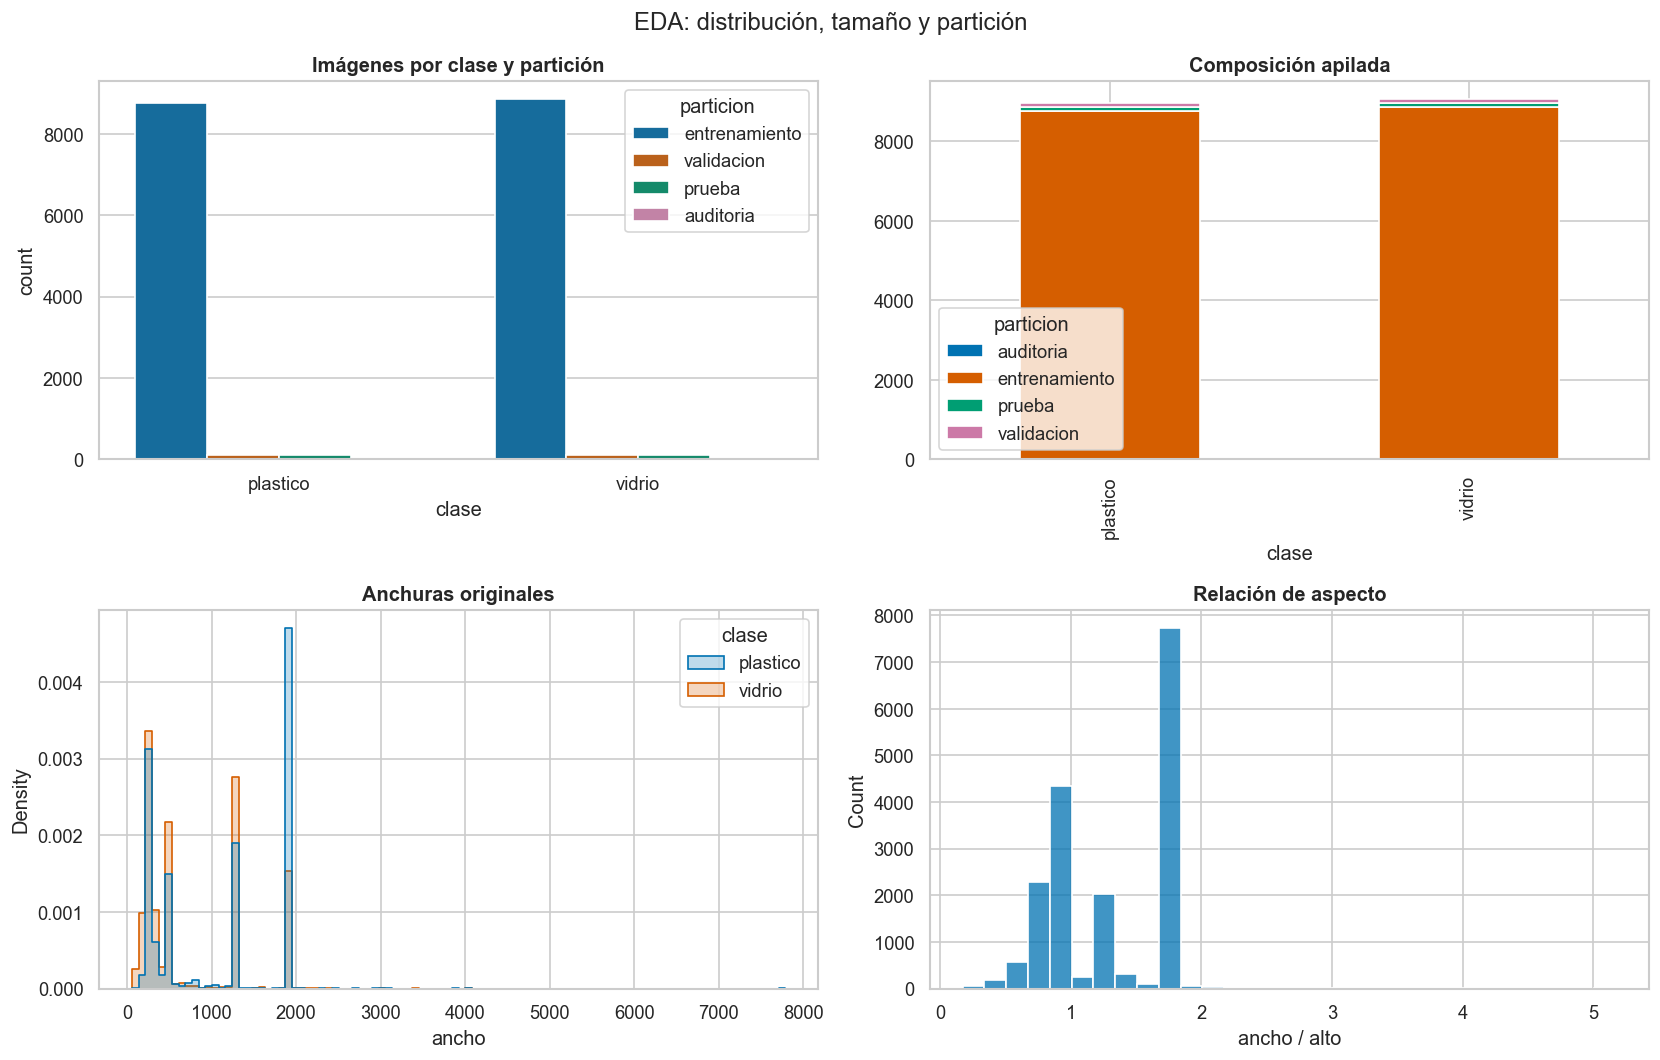

In [5]:
if ENTORNO_LISTO:
    manifest = pd.read_csv(RUNS / inventario.iloc[0].run_id / 'manifest.csv')
    split = json.loads((RUNS / inventario.iloc[0].run_id / 'split_manifest.json').read_text(encoding='utf-8'))
    incluidos = manifest[manifest.inclusion.astype(str).eq('True')].copy(); incluidos['particion'] = incluidos.motivo
    print('Filas:', len(manifest), '| incluidas:', len(incluidos), '| hashes únicos incluidos:', incluidos.sha256.nunique())
    print('Duplicados SHA incluidos:', incluidos.sha256.duplicated().sum(), '| conflictos de etiqueta:', incluidos.groupby('sha256').clase.nunique().gt(1).sum())
    display(incluidos.groupby(['particion','clase']).size().unstack(fill_value=0))
    display(manifest.loc[~manifest.inclusion.astype(str).eq('True')].groupby('motivo').size().rename('excluidas').to_frame())
    hashes_por_particion = incluidos.groupby('particion').sha256.agg(set)
    sesiones_por_particion = incluidos.assign(sesion=incluidos.sesion.fillna('externas')).groupby('particion').sesion.agg(set)
    assert all(not (hashes_por_particion[a] & hashes_por_particion[b]) for i,a in enumerate(hashes_por_particion.index) for b in hashes_por_particion.index[i+1:])
    assert all(not (sesiones_por_particion[a] & sesiones_por_particion[b]) for i,a in enumerate(sesiones_por_particion.index) for b in sesiones_por_particion.index[i+1:])
    fig, axes = plt.subplots(2, 2, figsize=(14, 9));
    sns.countplot(data=incluidos, x='clase', hue='particion', ax=axes[0,0]); axes[0,0].set_title('Imágenes por clase y partición')
    (incluidos.groupby(['clase','particion']).size().unstack(fill_value=0).plot(kind='bar', stacked=True, ax=axes[0,1], color=PALETA)); axes[0,1].set_title('Composición apilada')
    sns.histplot(incluidos, x='ancho', hue='clase', element='step', stat='density', common_norm=False, ax=axes[1,0]); axes[1,0].set_title('Anchuras originales')
    razon = incluidos.ancho/incluidos.alto; sns.histplot(razon.dropna(), bins=30, ax=axes[1,1], color=PALETA[0]); axes[1,1].set_title('Relación de aspecto'); axes[1,1].set_xlabel('ancho / alto')
    fig.suptitle('EDA: distribución, tamaño y partición'); fig.tight_layout()
    display(incluidos.assign(sesion=incluidos.sesion.fillna('externas')).groupby(['particion','sesion']).size().rename('imágenes').to_frame())
    print('Interpretación: los cambios de luz, fondo, JPEG y QVGA son cambios de dominio; separar por sesión mide mejor la generalización.')

El mosaico es descriptivo: no sustituye la prueba reservada ni se emplea para seleccionar el modelo.


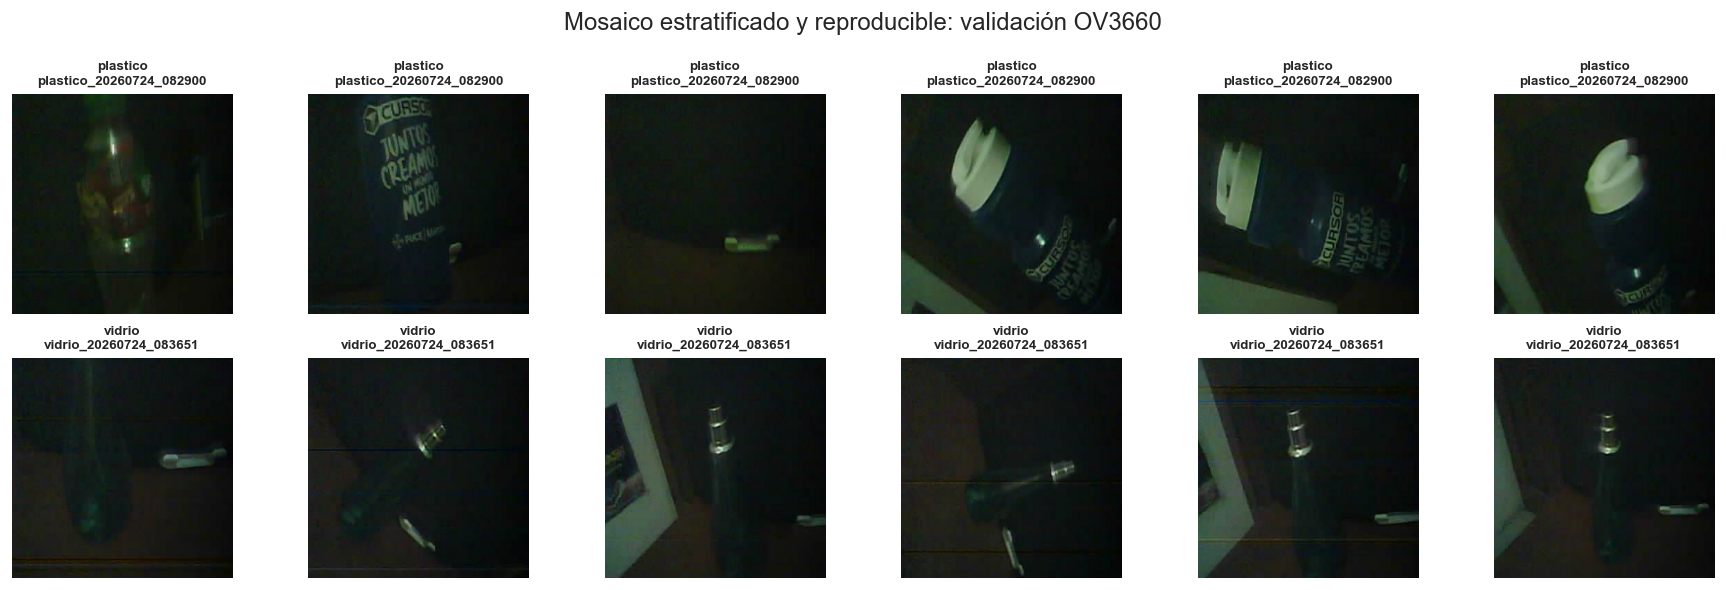

In [6]:
if ENTORNO_LISTO:
    muestra = pd.concat([grupo.sample(min(6, len(grupo)), random_state=SEMILLA) for _, grupo in incluidos[incluidos.particion.eq('validacion')].groupby('clase')], ignore_index=True)
    fig, axes = plt.subplots(2, 6, figsize=(15,5));
    for ax, fila in zip(axes.flat, muestra.itertuples()):
        ruta = resolver_imagen(fila)
        if ruta and sha256_archivo(ruta) == fila.sha256:
            ax.imshow(cargar_rgb_224(ruta).numpy().astype('uint8')); ax.set_title(f'{fila.clase}\n{fila.sesion}', fontsize=8)
        else: ax.text(.5,.5,'archivo no disponible',ha='center'); ax.set_title(fila.clase)
        ax.axis('off')
    fig.suptitle('Mosaico estratificado y reproducible: validación OV3660'); fig.tight_layout()
    print('El mosaico es descriptivo: no sustituye la prueba reservada ni se emplea para seleccionar el modelo.')

## 7. Hiperparámetros y 8. curvas de aprendizaje

El aprendizaje por transferencia comienza con el *backbone* congelado y una cabeza nueva; después se realiza *fine-tuning* con una tasa de aprendizaje menor. Early stopping guarda la época con mayor macro-F1 de validación. Tres semillas permiten observar estabilidad, no solo un resultado afortunado.

,run_id,arquitectura,semilla,batch_size,dropout,paciencia,mejor_epoca,epocas_ejecutadas,lr_cabeza,lr_fine_tuning,entrada,seleccion,perdida
0,efficientnetb0_20260809_004420_split42_seed1,efficientnetb0,1,32,0.3,6,12,18,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
1,efficientnetb0_20260809_004420_split42_seed2,efficientnetb0,2,32,0.3,6,15,21,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
2,efficientnetb0_20260809_004420_split42_seed3,efficientnetb0,3,32,0.3,6,16,22,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
3,mobilenetv2_20260809_004420_split42_seed1,mobilenetv2,1,32,0.3,6,27,33,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
4,mobilenetv2_20260809_004420_split42_seed2,mobilenetv2,2,32,0.3,6,18,24,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
5,mobilenetv2_20260809_004420_split42_seed3,mobilenetv2,3,32,0.3,6,23,29,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
6,mobilenetv3large_20260809_004420_split42_seed1,mobilenetv3large,1,32,0.3,6,22,28,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
7,mobilenetv3large_20260809_004420_split42_seed2,mobilenetv3large,2,32,0.3,6,23,29,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy
8,mobilenetv3large_20260809_004420_split42_seed3,mobilenetv3large,3,32,0.3,6,17,23,None,None,"224×224×3 RGB [0,255]",macro-F1 validación,categorical_crossentropy


Lectura: una brecha creciente entre entrenamiento y validación indica sobreajuste; mesetas tempranas, subajuste; la DE resume sensibilidad a la semilla.


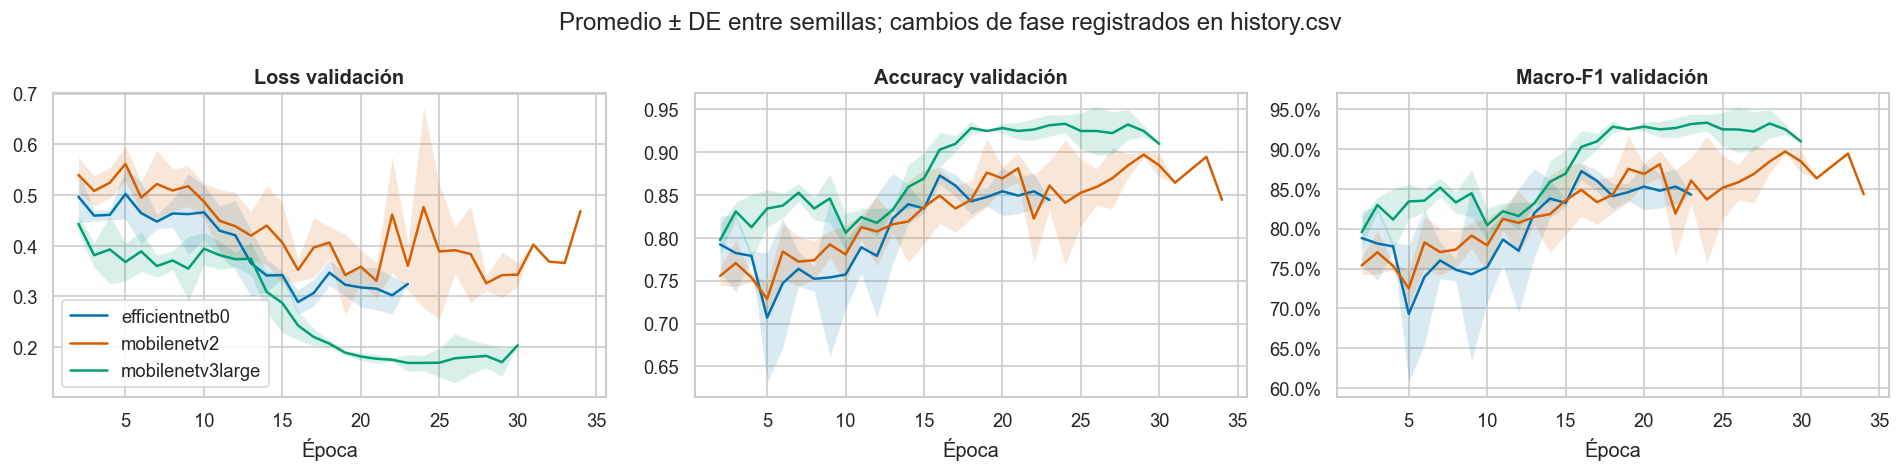

In [7]:
if ENTORNO_LISTO:
    hiper = inventario[['run_id','arquitectura','semilla','batch_size','dropout','paciencia','mejor_epoca','epocas_ejecutadas','lr_cabeza','lr_fine_tuning']].copy()
    hiper['entrada'] = '224×224×3 RGB [0,255]'; hiper['seleccion'] = 'macro-F1 validación'; hiper['perdida'] = 'categorical_crossentropy'
    display(hiper)
    historias = []
    for row in inventario.itertuples():
        h = pd.read_csv(RUNS/row.run_id/'history.csv'); h['run_id']=row.run_id; h['arquitectura']=row.arquitectura; h['semilla']=row.semilla; historias.append(h)
    historia = pd.concat(historias, ignore_index=True)
    fig, axes = plt.subplots(1,3,figsize=(16,4))
    for arquitectura, datos in historia.groupby('arquitectura'):
        medio=datos.groupby('epoch')[['val_loss','val_accuracy','val_macro_f1']].mean(); de=datos.groupby('epoch')[['val_loss','val_accuracy','val_macro_f1']].std().fillna(0)
        for ax, columna, titulo in zip(axes, ['val_loss','val_accuracy','val_macro_f1'], ['Loss validación','Accuracy validación','Macro-F1 validación']):
            ax.plot(medio.index+1, medio[columna], label=arquitectura); ax.fill_between(medio.index+1, medio[columna]-de[columna], medio[columna]+de[columna], alpha=.15); ax.set_title(titulo); ax.set_xlabel('Época')
    axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[0].legend(); fig.suptitle('Promedio ± DE entre semillas; cambios de fase registrados en history.csv'); fig.tight_layout()
    print('Lectura: una brecha creciente entre entrenamiento y validación indica sobreajuste; mesetas tempranas, subajuste; la DE resume sensibilidad a la semilla.')

## 9–12. Evaluación float32, comparación con INT8, matrices y calibración

Se evalúan exactamente las 199 imágenes de validación en el orden del manifiesto. Primero se verifica hash de todos los modelos y de las imágenes. Los controles V3 indicados abajo son **pruebas de coherencia**, no métricas insertadas: si el entorno no los reproduce, se marca la ejecución como no comparable y no se proclama ganador. Esto es crucial porque la versión del runtime puede alterar la deserialización o la inferencia cuantizada.

In [8]:
if ENTORNO_LISTO:
    validacion = incluidos[incluidos.particion.eq('validacion')].copy().reset_index(drop=True)
    rutas_val = [resolver_imagen(f) for f in validacion.itertuples()]
    DISPONIBLES_VAL = all(p is not None for p in rutas_val) and all(sha256_archivo(p) == f.sha256 for p,f in zip(rutas_val,validacion.itertuples()))
    print(f'Validación disponible e íntegra: {DISPONIBLES_VAL} ({len(rutas_val)} imágenes)')
    y_val = validacion.clase.map({c:i for i,c in enumerate(CLASES)}).to_numpy()
    RESULTADOS, ERRORES_EVALUACION = [], {}
    if DISPONIBLES_VAL and inventario[['hash_tflite_ok','hash_keras_ok']].all().all():
        for fila in inventario.itertuples():
            try:
                p_keras, modelo, lat_k = ejecutar_keras(RUNS/fila.run_id/'model.keras', rutas_val)
                p_int8, lat_i = ejecutar_tflite(RUNS/fila.run_id/'model.tflite', rutas_val)
                mk, mi = matriz_metricas(y_val,p_keras), matriz_metricas(y_val,p_int8)
                RESULTADOS.append({'run_id':fila.run_id,'arquitectura':fila.arquitectura,'semilla':fila.semilla, 'keras_macro_f1':mk['macro_f1'], 'int8_macro_f1':mi['macro_f1'], 'caida_f1':mk['macro_f1']-mi['macro_f1'], 'accuracy_keras':mk['accuracy'], 'accuracy_int8':mi['accuracy'], 'recall_plastico_keras':mk['por_clase'].iloc[0].recall, 'recall_plastico_int8':mi['por_clase'].iloc[0].recall, 'recall_vidrio_keras':mk['por_clase'].iloc[1].recall, 'recall_vidrio_int8':mi['por_clase'].iloc[1].recall, 'acuerdo':float((mk['y_pred']==mi['y_pred']).mean()), 'cambios':int((mk['y_pred']!=mi['y_pred']).sum()), 'desviacion_media_prob':float(np.abs(p_keras-p_int8).mean()), 'desviacion_max_prob':float(np.abs(p_keras-p_int8).max()), 'tflite_MB':fila.tflite_MB, 'latencia_p50_ms':lat_i['p50_ms'], 'latencia_p95_ms':lat_i['p95_ms'], 'cm_keras':mk['matriz'].tolist(), 'cm_int8':mi['matriz'].tolist(), 'p_keras':p_keras, 'p_int8':p_int8})
            except Exception as exc:
                ERRORES_EVALUACION[fila.run_id] = f'{type(exc).__name__}: incompatibilidad al cargar Keras; revisar la versión del runtime.'
    comparacion = pd.DataFrame([{k:v for k,v in r.items() if k not in {'p_keras','p_int8','cm_keras','cm_int8'}} for r in RESULTADOS])
    display(comparacion)
    if ERRORES_EVALUACION: print('EVALUACIÓN NO COMPLETA; no se usan resultados parciales como selección:', ERRORES_EVALUACION)
    # Controles independientes entregados para la corrida V3 correcta y el control MobileNetV2.
    REFERENCIA_QA = {'mobilenetv3large_20260809_004420_split42_seed1': {'keras_macro_f1':.9447,'int8_macro_f1':.4959,'acuerdo':.5327,'cambios':93}, 'mobilenetv2_20260809_004420_split42_seed2': {'keras_macro_f1':.9145,'int8_macro_f1':.8844,'acuerdo':.9397,'cambios':12}}
    CONTROL_V3_OK = False
    if len(comparacion) == 9:
        chequeos=[]
        for run_id, esperado in REFERENCIA_QA.items():
            real=comparacion.set_index('run_id').loc[run_id]
            chequeos += [abs(real[k]-v) <= .002 if k != 'cambios' else real[k] == v for k,v in esperado.items()]
        CONTROL_V3_OK=all(chequeos)
    print('CONTROL V3 CORRECTO:', 'APROBADO' if CONTROL_V3_OK else 'NO APROBADO — detener conclusión comparativa y revisar runtime/pipeline')

Validación disponible e íntegra: True (199 imágenes)


""


EVALUACIÓN NO COMPLETA; no se usan resultados parciales como selección: {'efficientnetb0_20260809_004420_split42_seed1': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'efficientnetb0_20260809_004420_split42_seed2': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'efficientnetb0_20260809_004420_split42_seed3': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'mobilenetv2_20260809_004420_split42_seed1': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'mobilenetv2_20260809_004420_split42_seed2': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'mobilenetv2_20260809_004420_split42_seed3': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'mobilenetv3large_20260809_004420_split42_seed1': 'TypeError: incompatibilidad al cargar Keras; revisar la versión del runtime.', 'mobilenetv3large_20260809_004420_spli

In [9]:
if ENTORNO_LISTO and CONTROL_V3_OK:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    largo = comparacion.melt(id_vars=['run_id','arquitectura','semilla'], value_vars=['keras_macro_f1','int8_macro_f1'], var_name='formato', value_name='macro_f1')
    sns.barplot(data=largo, x='run_id', y='macro_f1', hue='formato', ax=axes[0]); axes[0].tick_params(axis='x', rotation=90); axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[0].set_title('Macro-F1: float32 frente a INT8')
    sns.scatterplot(data=comparacion, x='tflite_MB', y='int8_macro_f1', size='latencia_p50_ms', hue='arquitectura', s=180, ax=axes[1]); axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1)); axes[1].set_title('Calidad, tamaño y latencia p50')
    fig.tight_layout()
    principales=['mobilenetv3large_20260809_004420_split42_seed1','mobilenetv2_20260809_004420_split42_seed2']
    fig, axes = plt.subplots(2,2,figsize=(10,8))
    for fila, run_id in enumerate(principales):
        r=next(x for x in RESULTADOS if x['run_id']==run_id)
        for col,(nombre,cm) in enumerate([('Keras float32',r['cm_keras']),('TFLite INT8',r['cm_int8'])]):
            sns.heatmap(np.array(cm), annot=True, fmt='d', cmap='Blues', xticklabels=CLASES, yticklabels=CLASES, ax=axes[fila,col]); axes[fila,col].set_title(f'{run_id} — {nombre}'); axes[fila,col].set_xlabel('Predicha'); axes[fila,col].set_ylabel('Real')
    fig.tight_layout()
    print('Las matrices revelan qué tipo de contaminación de contenedor puede producir cada falso positivo/falso negativo; no se interpreta la exactitud aislada.')
elif ENTORNO_LISTO:
    print('Gráficos de comparación bloqueados deliberadamente: falta reproducir el control V3 correcto.')

Gráficos de comparación bloqueados deliberadamente: falta reproducir el control V3 correcto.


In [10]:
if ENTORNO_LISTO and CONTROL_V3_OK:
    candidato = comparacion.sort_values(['int8_macro_f1','caida_f1','latencia_p50_ms'], ascending=[False,True,True]).iloc[0]
    semaforo = comparacion.copy()
    semaforo['F1≥85%'] = semaforo.int8_macro_f1.ge(.85); semaforo['recall plástico≥85%'] = semaforo.recall_plastico_int8.ge(.85); semaforo['recall vidrio≥85%'] = semaforo.recall_vidrio_int8.ge(.85)
    semaforo['caída F1≤2pp'] = semaforo.caida_f1.le(.02); semaforo['caída recall/clase≤4pp'] = ((semaforo.recall_plastico_keras-semaforo.recall_plastico_int8).le(.04) & (semaforo.recall_vidrio_keras-semaforo.recall_vidrio_int8).le(.04))
    semaforo['latencia aceptable'] = semaforo.latencia_p95_ms.le(30); semaforo['tamaño aceptable'] = semaforo.tflite_MB.le(5); semaforo['prueba reservada'] = 'PENDIENTE'
    display(semaforo[['run_id','keras_macro_f1','int8_macro_f1','caida_f1','F1≥85%','recall plástico≥85%','recall vidrio≥85%','caída F1≤2pp','caída recall/clase≤4pp','latencia aceptable','tamaño aceptable','prueba reservada']])
    print('Mejor Keras float32:', comparacion.loc[comparacion.keras_macro_f1.idxmax(),'run_id'])
    print('Mejor TFLite INT8 según calidad, caída y latencia:', candidato.run_id)
    print('Decisión provisional: V3 gana en Keras; V2 semilla 2 conserva mejor la cuantización indicada por el control, pero su caída de 3.02 pp excede el umbral estricto de 2 pp.')

## 13. Prueba reservada (bloqueada)

**PRUEBA RESERVADA PENDIENTE — no se ejecuta automáticamente.** La prueba debe contener exactamente 100 imágenes de plástico y 100 de vidrio, con hashes y sesiones declarados, y no tener una evaluación previa registrada. Tras congelar un único candidato, esta operación requiere una confirmación humana explícita; por ello el cuaderno solo realiza el diagnóstico de disponibilidad.

In [11]:
if ENTORNO_LISTO:
    prueba = incluidos[incluidos.particion.eq('prueba')].copy(); rutas_prueba = [resolver_imagen(f) for f in prueba.itertuples()]
    estado_prueba = {'total':len(prueba), 'por_clase':prueba.clase.value_counts().to_dict(), 'archivos_disponibles':all(x is not None for x in rutas_prueba), 'hashes_validos':all(p is not None and sha256_archivo(p)==f.sha256 for p,f in zip(rutas_prueba,prueba.itertuples())), 'evaluacion_previa': any((RUNS/r/'prueba_metricas.json').exists() for r in inventario.run_id)}
    print(estado_prueba)
    print('Las 200 imágenes de prueba reservada no se evalúan desde este cuaderno sin congelar un candidato y recibir confirmación explícita. La selección permanece provisional.')

{'total': 200, 'por_clase': {'plastico': 100, 'vidrio': 100}, 'archivos_disponibles': True, 'hashes_validos': True, 'evaluacion_previa': False}
Las 200 imágenes de prueba reservada no se evalúan desde este cuaderno sin congelar un candidato y recibir confirmación explícita. La selección permanece provisional.


## 14. Relación con el sistema híbrido, conclusiones y resumen ejecutivo

El clasificador local es binario: siempre devuelve plástico o vidrio, incluso para objetos fuera de distribución. La política híbrida toma tres capturas: hay tres votos del proveedor/sistema experto y tres del modelo local. Los seis votos se cuentan juntos; `desconocido` es abstención, gana la clase con más votos y un empate se resuelve con la preferencia del proveedor. Una respuesta incompleta o una confusión sin desempate devuelve `desconocido`, que no abre ninguna compuerta.

**Conclusión para exposición.** MobileNetV3-Large fue el mejor modelo Keras float32 en validación, pero su exportación INT8 presentó una regresión severa en el control V3. MobileNetV2 semilla 2 tuvo menor macro-F1 float32, pero preservó mejor sus predicciones al cuantizarse; aun así, su caída de 3.02 pp supera el umbral estricto de 2 pp. En consecuencia, arquitectura, modelo entrenado y artefacto desplegable no son sinónimos, y ningún modelo es definitivo sin la prueba reservada.

Limitaciones: validación de 199 imágenes, ausencia de clases fuera de distribución, dependencia del dominio OV3660/QVGA, y prueba reservada pendiente. Próximos pasos: resolver cualquier incompatibilidad de runtime, congelar un candidato mediante criterios predefinidos y ejecutar una sola prueba reservada con trazabilidad.